In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
# import geopy.distances
from tqdm import tqdm
from sklearn.decomposition import PCA
from scipy.stats import zscore
import seaborn as sns
sys.path.append('../src/')
sys.path.append('../content/')
import data_utils as du
import vis_utils as vu
import sample_locations as sl
import overlap_utils as ou

In [6]:
folder = '/Users/tplas/Downloads/'

fname = 'cropharvest_cleaned_Kenya.csv'

fpath = os.path.join(folder, fname)

df_crop = pd.read_csv(fpath)

from collections import Counter
df_crop.label_name.value_counts(), len(df_crop)

(label_name
 millet            200
 Other             105
 red clover         58
 tournesol          23
 white sorghum      16
 eggplant           10
 menthe              7
 cherries            3
 winter wheat        2
 colza dhiver       2
 avoine dhiver      2
 broadleaf           2
 winter rye          1
 ryegrass            1
 radis               1
 Name: count, dtype: int64,
 2855)

In [15]:
folder = '/Users/tplas/Downloads/'

fname = 'biomass_cleaned.csv'

fpath = os.path.join(folder, fname)

df_biomass = pd.read_csv(fpath)

len(df_biomass), sum(df_biomass.biomass_center != -9999.0)
gdf_biomass = gpd.GeoDataFrame(df_biomass, geometry=gpd.points_from_xy(df_biomass.lon, df_biomass.lat))
gdf_biomass_centre = gdf_biomass[gdf_biomass.biomass_center != -9999.0]
len(gdf_biomass_centre)

4585

<Axes: >

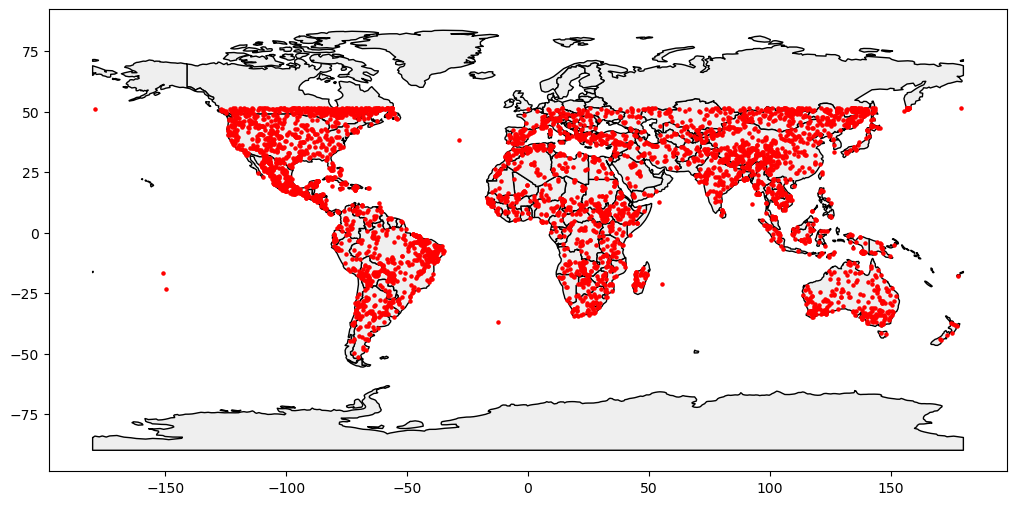

In [18]:
countries = gpd.read_file('/Users/tplas/data/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp')

fig, ax = plt.subplots(figsize=(20,6))
countries.plot(ax=ax, color="#EFEFEF", edgecolor='black')
gdf_biomass_centre.plot(ax=ax, color='red', markersize=5)